# Experiment — does resolving inlets explain the inland MOTF misses?

**Hypothesis.** The MOTF spatial validation shows blue *misses* clustered in the back-bays / inland lows (Shrewsbury, Wreck Pond, Shark River, Deal Lake), which we suspect are throttled because the 50 m grid can't resolve the narrow inlet channels that connect them to the ocean. SnapWave wouldn't fix that — it's a grid/DEM problem, not wave physics.

**Test.** Build a *separate* SFINCS model in `model_inlet_test/` that's identical to the working model except for an extra top-priority DEM layer: hand-drawn inlet centerlines burned at −2 m NAVD88 (`inlet_channels_burn`, built by `scripts/build_inlet_channels.py`). Then re-score the MOTF CSI/POD/FAR and look at which inland misses turned into hits.

**Isolation.** The working `model/` directory and the main notebook `sfincs-asbury-sandy.ipynb` are **never touched** by this experiment. Everything writes to `model_inlet_test/`.

**Cost.** This is a full Phase-1 rebuild (the subgrid tables encode bathymetry, so a DEM edit requires regenerating them) + Phase 2 + a SFINCS Docker run. Plan ~10 min on first run; iterate by tweaking `INLETS` in `scripts/build_inlet_channels.py` and re-running.

**To refine which inlets / where:** edit the `INLETS` polylines in [scripts/build_inlet_channels.py](../scripts/build_inlet_channels.py), re-run the build, then re-run this notebook.

In [1]:
# Imports
import os
import subprocess
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray
import xarray as xr
from hydromt._utils import log
from hydromt_sfincs import DATADIR, SfincsModel, utils
from shapely.geometry import Point


## Phase 1 — Build with inlet-burned DEM

Same logic as the main notebook, only two differences: `model_root` points at `../model_inlet_test`, and the elevation merge has `inlet_channels_burn` prepended as the top-priority layer.

In [2]:
model_root = "../model_inlet_test"

log.initialize_logging()
log.set_log_level(log_level=30)  # Only errors and critical

# Add file handler to log to a file
log_file = Path(model_root) / "hydromt_sfincs.log"
logger = log._add_filehandler(log_file)

# Add data catalogs
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

# Create model
sf = SfincsModel(data_libs=data_libs, root=model_root, mode="w+", write_gis=True)


2026-05-24 18:43:30,878 - hydromt.model.model - model - WARNING - No region component found in components.


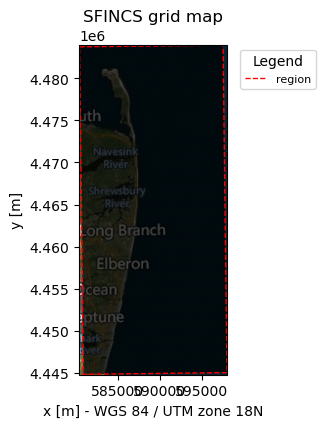

In [3]:
# Create grid from region.  50 m (was 100 m) so the 1 m topobathy data
# is sampled into a grid that can actually resolve the barrier-island
# dune line; subgrid pixels below give a ~3 m effective resolution.
sf.grid.create_from_region(
    region={"geom": "/home/zagreus/nj_sandy_sfincs/data/region.geojson"},
    res=50,
    rotated=True,
    crs="utm",
)

# Show model grid outline
_ = sf.plot_basemap(
    variable="grid",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
    grid_kwargs={"linewidth": 0.3},
)


2026-05-24 18:43:32,121 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - Dataset [580497.7487530684, 4444839.88830544, 597947.7487530684, 4483889.88830544] does not fully cover bbox [580039.594, 4444632.655, 598474.328, 4484146.091]


2026-05-24 18:43:46,689 - hydromt.hydromt_sfincs.components.grid.elevation - elevation - WARNING - Interpolate elevation at 1 cells


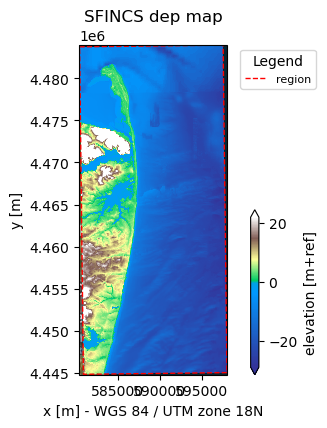

In [4]:
elevation_list = [
    {"elevation": "inlet_channels_burn"},  # EXPERIMENT: hand-burned inlets at -2 m
    {"elevation": "usace_nj_2010"},  # 1 m pre-Sandy topobathy: dunes, beach, surf zone
    {"elevation": "cudem_nj"},  # 3 m fill: inlet channels + shelf
    {
        "elevation": "nj_10ft_dem",
        "zmin": 0.001,
    },  # 3 m fill: inland (drop hydroflat water)
    {"elevation": "gebco_nj"},  # 450 m offshore tail
]

sf.elevation.create(elevation_list=elevation_list, buffer_cells=1)

# Plot the merged topobathy (colour limits set between -25 m and +10 m to show NJ shelf)
_ = sf.plot_basemap(
    variable="dep",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
)


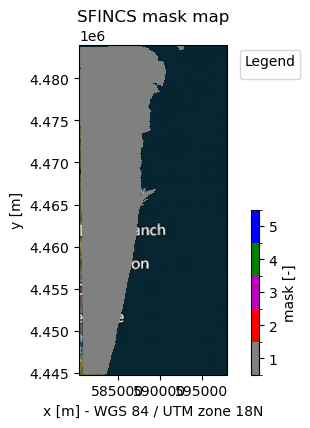

In [5]:
# All cells with elevation >= -10 m are considered active
# The NJ shelf is shallow, so -10 m captures it without going too far offshore
sf.mask.create_active(zmin=-10)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=10,
)

2026-05-24 18:43:48,799 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


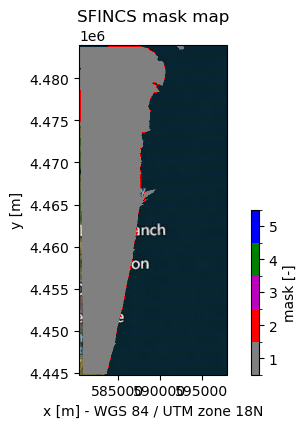

In [6]:
# Mark offshore edge cells (depth > 1 m) as water level boundary cells
sf.mask.create_boundary(
    btype="waterlevel",
    zmax=-1,
    reset_bounds=True,
)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

2026-05-24 18:43:49,745 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


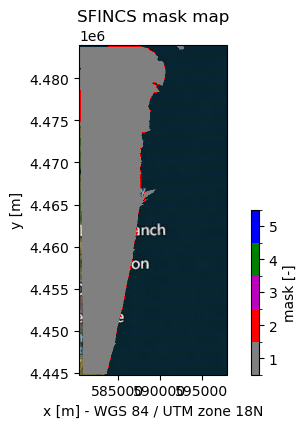

In [7]:
# Add outflow cells (mask=3) on the lateral/inland edges of the active mask.
# zmin/zmax restricts to channels/back-bay cells; high dune cells stay as
# regular interior land (no outflow needed). reset_bounds=False preserves
# the offshore water-level boundary set above.
sf.mask.create_boundary(btype="outflow", zmin=-1, zmax=2, reset_bounds=False)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

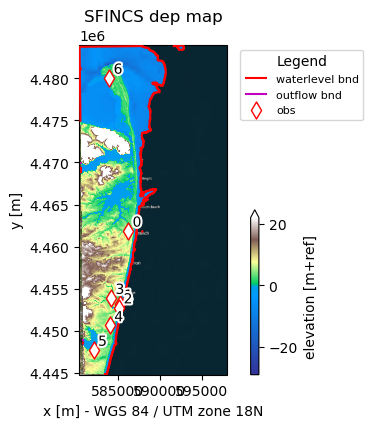

In [8]:
# Project obs points + the Sandy Hook NOAA gauge for validation. The Sandy
# Hook 8531680 gauge falls inside the domain — modeled zs(t) here vs the
# observed record (valid up to the gauge failure ~23:00 UTC 2012-10-29) is the
# cleanest single-point temporal check; the USGS HWMs (Phase 3) add the
# spatial check across the domain.
obs_gdf = gpd.read_file("../data/obs.geojson")
sandy_hook = gpd.GeoDataFrame(
    {"name": ["sandy_hook_gauge"]},
    geometry=[Point(-74.0091, 40.4669)],  # NOAA 8531680
    crs="EPSG:4326",
)
obs_all = gpd.GeoDataFrame(
    pd.concat([obs_gdf, sandy_hook], ignore_index=True),
    crs="EPSG:4326",
)
sf.observation_points.create(locations=obs_all, merge=False)

_ = sf.plot_basemap(
    variable="dep",
    plot_geoms=True,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=12,
)

In [9]:
# NLCD → Manning reclass table (hydromt_sfincs built-in; SFBD-tuned — TODO: swap for CONUS table)
reclass_table = os.path.join(DATADIR, "lulc", "NLCD_SFBD_mapping.csv")

elevation_list = [
    {"elevation": "usace_nj_2010"},                # 1 m pre-Sandy topobathy: dunes, beach, surf zone
    {"elevation": "cudem_nj"},                     # 3 m fill: inlet channels + shelf
    {"elevation": "nj_10ft_dem", "zmin": 0.001},   # 3 m fill: inland (drop hydroflat water)
    {"elevation": "gebco_nj"},                     # 450 m offshore tail
]
roughness_list = [{"lulc": "nlcd_2012", "reclass_table": reclass_table}]

# nr_subgrid_pixels=8 (was 16) so the 50 m grid samples ~3 m effective —
# fine enough to capture the dune line from the 1 m USACE topobathy.
sf.subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    nr_subgrid_pixels=8,
    write_dep_tif=True,
    write_man_tif=True,
)

2026-05-24 18:43:52,399 - hydromt.gis.raster - raster - WARNING - The nodata value None is not in the reclass table.None will be used for the params.
2026-05-24 18:43:59,241 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 1127 subgrid pixels with default values
2026-05-24 18:44:10,353 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 391 subgrid pixels with default values
2026-05-24 18:44:20,748 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 6194 subgrid pixels with default values


In [10]:
# --- End of Phase 1: write the static model to disk ---
# Grid, elevation, mask, subgrid tables, and obs points are now on disk.
# None of this depends on forcing, so you don't need to rebuild it when
# iterating on water level / wind / pressure — Phase 2 reopens from here.
sf.write()

# Free the build-time memory. The data-catalog cache + source DEMs held
# ~10 GB resident after the build; Phase 2 opens a fresh handle and doesn't
# need any of it. (Restarting the kernel here works just as well.)
del sf
import gc; gc.collect()

1022

## Phase 2 — Forcing & run

> **Restart the kernel between Phase 1 and Phase 2** (same as the main notebook — the Phase-1 `del sf; gc.collect()` frees memory but a clean kernel is safer for the subgrid load).

All Phase-2 cells are unmodified clones of the main notebook; they pick up `model_root` from the Phase-2 reopen cell.

In [11]:
# --- Phase 2 entry point: reopen the static model from disk ---
# mode="r+" opens the existing Phase 1 model and allows updating it in place.
# Re-defined here (not just in the Phase 1 init cell) so this works as a
# standalone entry point after a kernel restart.
model_root = "../model_inlet_test"
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

sf = SfincsModel(model_root, data_libs=data_libs, mode="r+")

2026-05-24 18:44:29,678 - hydromt.model.model - model - WARNING - No region component found in components.


In [12]:
# Set the simulation period to cover Hurricane Sandy's landfall.
# tstart == tref so the model gets ~24 h of calm tide before Sandy arrives.
# Without that head-start, at the first step the boundary jumps from zsini=0
# to ~1.5 m (Battery is mid-tide on 10-29 00:00) and the model rings for an
# hour before settling — visible as a spike/oscillation in the Sandy Hook
# validation plot at the start of the run.
sf.config.update(
    {
        "tref": datetime(2012, 10, 28),
        "tstart": datetime(2012, 10, 28),
        "tstop": datetime(2012, 10, 31),
        "tspinup": 3600.0,  # smoothly ramp the boundary over the first hour
        # instead of step-applying it (belt-and-suspenders
        # on top of the 24 h of pre-storm tide above).
        "coriolis": 1,  # on: 40 N + sustained alongshore Sandy winds.
        # Expect only a small correction though — with
        # observed-gauge boundaries the regional Ekman
        # setup is already in the BC; this just adds the
        # setup generated within the ~40 km domain.
        "latitude": 40.32,  # domain-center latitude (deg). SFINCS needs this
        # to compute the Coriolis parameter — without it
        # the run log reports "Coriolis: no" even with
        # coriolis=1 set. f-plane is fine at 40 km
        # (Coriolis varies <5% across the domain).
        "advection": 1,  # advection term in the momentum equations. Already
        # the hydromt-sfincs default (always written to
        # sfincs.inp), so the run log has shown "Advection:
        # yes" all along — set explicitly here for the
        # record. Matters around the inlet and steep surge
        # gradients, and is required once waves/IG are
        # added later (per the Carolinas/Florence paper).
        "dtmapout": 3600.0,  # hourly map snapshots -> creates sfincs_map.nc
        "dtmaxout": 86400.0,  # write max values once per day
        "dthisout": 600.0,  # observation point output every 10 min
    }
)

# Apply observed NOAA CO-OPS water levels to the boundary cells.
# noaa_sandy_nj.nc holds 3 complete-record stations: The Battery (8518750),
# Atlantic City (8534720), Cape May (8536110). Sandy Hook (8531680) is
# deliberately excluded — its gauge failed mid-storm and its NaN tail
# collapses the northern boundary (see noaa_sandy_validation.nc for that
# record, used for validation only).
#
# merge=False is REQUIRED here: in Phase 2 the model is opened mode="r+",
# which loads any existing bnd forcing from disk. The default merge=True
# would append to that stale forcing — and because the old Sandy Hook
# station isn't in the new file, nothing dedupes it away, so it survives
# and write() then skips ("no changes detected"). merge=False replaces.
#
# buffer=100000 m (was 50000): the southern boundary is ~88 km from Atlantic
# City, so a 50 km buffer caught only The Battery and forced the whole
# boundary uniformly. 100 km pulls in Atlantic City too, so the boundary
# keeps Sandy's real alongshore gradient (Battery ~3.4 m north, AC ~1.9 m south).
sf.water_level.create(
    geodataset="noaa_sandy_nj",
    buffer=100000,
    merge=False,
)


In [13]:
import numpy as np
from pyproj import Transformer

# β_f stays at 0.05 — the minimum-defensible NJ foreshore slope. It is now a
# single global coefficient applied to a *spatially-varying* wave field
# (below), so the alongshore contrast comes from H0/Tp, not from β_f.
BETA_F = 0.05
GRAVITY = 9.81

# --- Spatially-varying Stockdon setup from the ERA5 wave field ----------------
# The earlier version added one uniform buoy-derived setup at every boundary
# point. That over-bumps the sheltered north (Sandy Hook Bay) while under-
# serving the high-energy open coast. The water-level boundary has only TWO
# support points (The Battery ~40.70 N, Atlantic City ~39.36 N) which SFINCS
# interpolates alongshore. We sample the nearest *offshore* ERA5 node to EACH
# support point and add its own Stockdon setup -> a north–south gradient.
wl = sf.water_level.data
bzs = wl["bzs"].load().copy()
pt_dim = next(d for d in bzs.dims if d != "time")   # alongshore support-point dim
bnd_times = wl["time"]

# Support points are stored as a `geometry` variable (shapely Points in the
# model CRS) -> pull x/y, reproject to lon/lat for ERA5.
geom = np.atleast_1d(wl["geometry"].values)
px = np.array([g.x for g in geom], dtype="float64")
py = np.array([g.y for g in geom], dtype="float64")
to_wgs = Transformer.from_crs(sf.crs, 4326, always_xy=True)
lons, lats = to_wgs.transform(px, py)

waves = sf.data_catalog.get_rasterdataset("era5_waves_nj")
hs_all, tp_all = waves["hs"], waves["tp"]

# Flatten to a 1-D list of VALID offshore nodes (swh is NaN over land), so the
# nearest-node search is unambiguous about (y, x) ordering.
vmask = np.isfinite(hs_all).any("time").values            # (y, x)
lon2d, lat2d = np.meshgrid(hs_all["x"].values, hs_all["y"].values)
iy, ix = np.where(vmask)
vlon, vlat = lon2d[vmask], lat2d[vmask]

print(f"β_f = {BETA_F}; per-support-point ERA5 Stockdon setup:")
for i in range(bzs.sizes[pt_dim]):
    k = int(np.argmin((vlon - lons[i]) ** 2 + (vlat - lats[i]) ** 2))
    jy, jx = int(iy[k]), int(ix[k])
    hs = hs_all.isel(y=jy, x=jx)
    tp = tp_all.isel(y=jy, x=jx)
    L0 = GRAVITY * tp ** 2 / (2.0 * np.pi)
    eta = (0.35 * BETA_F * np.sqrt(hs * L0)).fillna(0.0)
    eta_b = eta.interp(time=bnd_times, kwargs={"fill_value": 0.0})
    bzs[{pt_dim: i}] = bzs.isel({pt_dim: i}) + eta_b
    print(f"  pt {i} (lat {lats[i]:.2f}) -> node ({vlon[k]:.1f},{vlat[k]:.1f}) "
          f"hs_peak {float(hs.max()):.1f} m -> setup_peak {float(eta_b.max()):.2f} m")

sf.water_level.data["bzs"] = bzs
print(f"boundary bzs peak after setup: {float(bzs.max()):.2f} m")


β_f = 0.05; per-support-point ERA5 Stockdon setup:
  pt 0 (lat 40.70) -> node (-74.0,40.0) hs_peak 8.6 m -> setup_peak 0.87 m
  pt 1 (lat 39.35) -> node (-74.5,39.0) hs_peak 6.9 m -> setup_peak 0.78 m
boundary bzs peak after setup: 4.22 m


In [14]:
# ERA5 file is pre-renamed to hydromt_sfincs conventions
# (wind10_u, wind10_v in m/s; press_msl in Pa; coords time/y/x).
# Both methods clip to the model bbox + time range internally.
sf.wind.create(wind="era5_nj")
sf.pressure.create(press="era5_nj")

In [15]:
# AORC precip is accumulated mm per 1-hour interval -> cumulative_input=True.
# aggregate=False keeps it spatially distributed (writes netamprfile / sfincs_netampr.nc).
sf.precipitation.create(precip="aorc_sandy_nj", cumulative_input=True, aggregate=False)

_pr = sf.precipitation.data
_var = "precip_2d" if "precip_2d" in _pr else list(_pr.data_vars)[0]
print(f"precip [mm/hr]: peak={float(_pr[_var].max()):.2f}  "
      f"domain-mean={float(_pr[_var].mean()):.3f}  "
      f"grid={dict(_pr[_var].sizes)}")

precip [mm/hr]: peak=13.30  domain-mean=0.468  grid={'time': 73, 'y': 50, 'x': 25}


In [16]:
# Daily-mean discharge at 2 domain inflows (Shark River, Navesink). The
# geodataset's point coords place the src cells; merge=False replaces any
# stale src/dis loaded by r+. Writes sfincs.src + sfincs.dis (no mask edit).
sf.discharge_points.create(geodataset="usgs_sandy_discharge", merge=False)

_dis = sf.discharge_points.data
print(f"discharge src points: {_dis.sizes.get('index', _dis.sizes.get('stations'))}  "
      f"peak={float(_dis['dis'].max()):.2f} m3/s")

discharge src points: 2  peak=7.87 m3/s


In [17]:
# SCS Curve Number infiltration (static soil property). antecedent_moisture=None
# -> read the 'cn' variable (CN II / average) directly. Writes sfincs.scs + scsfile.
# SCS is a rainfall-loss method: it only removes infiltration from precipitation,
# never from the surge, so coastal inundation depth is unaffected.
sf.infiltration.create_cn(cn="cn_nj", antecedent_moisture=None)

_scs = sf.grid.data["scs"]
print(f"SCS max soil-moisture retention S [inch]: "
      f"mean={float(_scs.where(_scs > 0).mean()):.2f}  max={float(_scs.max()):.2f}  "
      f"(higher S = more infiltration capacity; S=0 over water/impervious)")

2026-05-24 18:44:30,278 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: scs
SCS max soil-moisture retention S [inch]: mean=443.78  max=990.00  (higher S = more infiltration capacity; S=0 over water/impervious)


In [18]:
# write all model files to disk
sf.write()

# Workaround: hydromt-sfincs (v2.0.0rc2 on disk) silently drops `latitude`
# from sfincs.inp even when set via config.update. We confirmed empirically:
#   - sf.config.get("latitude") returns 40.32 right after the update
#   - but post-write the inp has no latitude line, AND in-memory `latitude`
#     reverts to 0.0 (sf.write() resets something internally)
# Without `latitude`, SFINCS disables Coriolis (log: "Coriolis: no") even
# with `coriolis = 1` set. Patch the inp directly. Idempotent; remove once
# upstream fix lands.
LATITUDE_DEG = 40.32   # keep in sync with the config.update cell above
inp = Path(model_root) / "sfincs.inp"
text = inp.read_text()
print(f"sf.config.get('latitude') at write-time: {sf.config.get('latitude')}")
if "\nlatitude" in text:
    print(f"sfincs.inp already has a latitude line — leaving it alone")
else:
    text = text.replace(
        "coriolis             = 1",
        f"coriolis             = 1\nlatitude             = {LATITUDE_DEG}",
    )
    inp.write_text(text)
    print(f"patched sfincs.inp: added latitude = {LATITUDE_DEG}")

sf.config.get('latitude') at write-time: 40.32
sfincs.inp already has a latitude line — leaving it alone


In [19]:
log_path = Path(model_root) / "sfincs_log.txt"
model_abs = Path(model_root).resolve()

# Remove stale output files before running — Docker writes them as root, and SFINCS
# gets "NetCDF: Not a valid ID" errors if it tries to overwrite root-owned files.
subprocess.run(
    [
        "docker", "run", "--rm",
        "-v", f"{model_abs}:/data",
        "--entrypoint", "/bin/sh",
        "deltares/sfincs-cpu:latest",
        "-c", "rm -f /data/sfincs_map.nc /data/sfincs_his.nc",
    ],
    capture_output=True,
)

print(f"Running SFINCS via Docker on {model_abs} ...")
with open(log_path, "w") as log_file:
    result = subprocess.run(
        [
            "docker", "run", "--rm",
            "-v", f"{model_abs}:/data",
            "deltares/sfincs-cpu:latest",
        ],
        stdout=log_file,
        stderr=subprocess.STDOUT,
    )
print(f"Done (return code {result.returncode})")


Running SFINCS via Docker on /home/zagreus/nj_sandy_sfincs/model_inlet_test ...
Done (return code 0)


In [20]:
# Read the SFINCS log file
log_path = Path(model_root) / "sfincs_log.txt"
if log_path.exists():
    print(log_path.read_text())
else:
    print("No log file found — SFINCS has not run yet.")


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.@@...@@.:.:.@@~::::.
     .::~@@@@@@@@@@.....@@@@@@@@@~::.
       ..:~~~~~~~:.......:~~~~~~~:.

In [21]:
# Check that output files were created
map_nc = Path(model_root) / "sfincs_map.nc"
his_nc = Path(model_root) / "sfincs_his.nc"

print(f"sfincs_map.nc exists: {map_nc.exists()}")
print(f"sfincs_his.nc exists: {his_nc.exists()}")

sfincs_map.nc exists: True
sfincs_his.nc exists: True


## Phase 3 — Re-score MOTF CSI and compare to baseline

The MOTF spatial-validation cell is the same as in the main notebook. The final cell below loads the *baseline* run (the working `model/` directory) independently and reports the CSI / POD / FAR **delta** plus a "what changed" map: where misses turned into hits (the inlet-burn benefit) and where any new misses or false alarms appeared.

In [22]:
# Open the model read-only for result inspection. Defined standalone so the
# Visualization section works after a kernel restart (doesn't depend on the
# Phase 1 / Phase 2 build cells still being in scope).
model_root = "../model_inlet_test"
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]
model_abs = Path(model_root).resolve()

mod = SfincsModel(model_root, data_libs=data_libs, mode="r")
mod.output.read()

print("Output variables available:")
list(mod.output.data.keys())

2026-05-24 18:45:49,434 - hydromt.model.model - model - WARNING - No region component found in components.
2026-05-24 18:45:49,508 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-05-24 18:45:49,509 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-05-24 18:45:49,509 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: qinf
2026-05-24 18:45:49,510 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zb
2026-05-24 18:45:49,510 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zs
2026-05-24 18:45:49,511 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zsmax
2026-05-24 18:45:49,511 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: total_runtime
2026-05-24 18:45:49,511 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: averag

['inp',
 'msk',
 'qinf',
 'zb',
 'zs',
 'zsmax',
 'total_runtime',
 'average_dt',
 'status',
 'point_zb',
 'point_zs',
 'point_qinf']

In [23]:
# Reuse `mod` opened above — no need to open a second SfincsModel
da_zsmax = mod.output.data["zsmax"].max(dim="timemax")

# Load the high-res subgrid DEM (written during build via write_dep_tif=True)
depfile = str(model_abs / "subgrid" / "dep_subgrid.tif")
da_dep = mod.data_catalog.get_rasterdataset(depfile)
print(f"Subgrid DEM shape: {da_dep.shape}, resolution: {da_dep.rio.resolution()}")

# Downscale water level to subgrid resolution, then drop deep-ocean cells
# (dep > -0.5) so the open shelf doesn't dominate the flood-map colour scale.
da_hmax = utils.downscale_floodmap(zsmax=da_zsmax, dep=da_dep, hmin=0.05)
da_hmax = da_hmax.where(da_dep > -0.5)

Subgrid DEM shape: (6224, 2728), resolution: (6.249566282166736, 6.249566282166805)


MOTF flooded land in domain : 38.3 km2
Model wet land in domain    : 31.0 km2
  hits  21.9  miss  16.4  false-alarm   9.1  km2
  CSI=0.46   POD (hit rate)=0.57   FAR=0.29


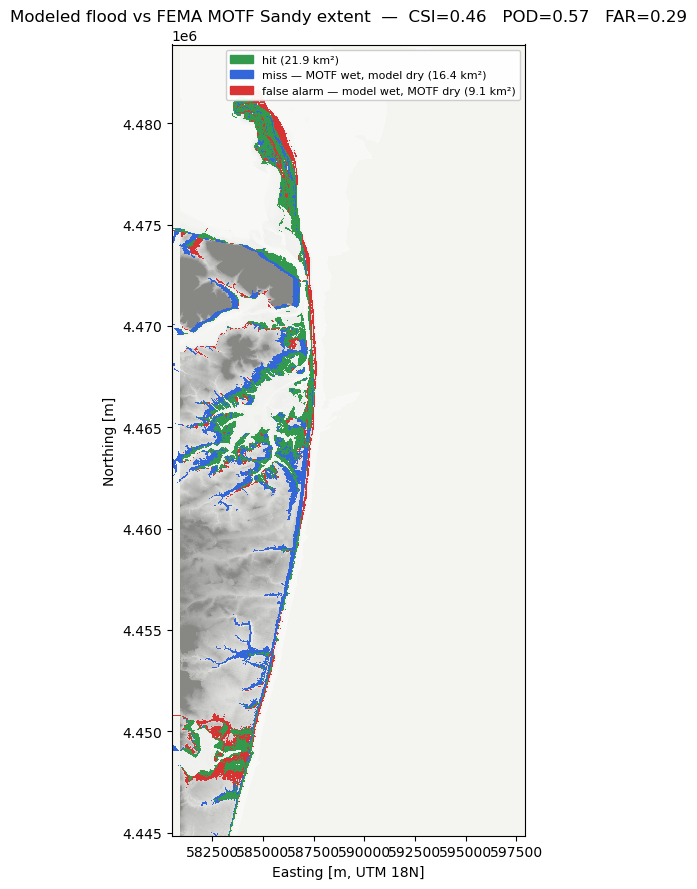

In [24]:
# Spatial-extent validation vs FEMA MOTF Sandy surge footprint.
# Both rasters are EPSG:32618, so we sample model cells at MOTF pixel centers in
# pure numpy — no GDAL warping needed (avoids known reproject crashes in this env).
import numpy as np
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

DEPTH_MIN = 0.15   # m; match the HWM cell's wet threshold

with rasterio.open("/home/zagreus/nj_sandy_sfincs/data/validation/sandy_motf_extent.tif") as r:
    motf = r.read(1); mtf = r.transform; m_nd = r.nodata
mod_t = da_dep.rio.transform()
mh, mw = motf.shape

# Map MOTF pixel centers -> nearest model subgrid pixel index (both UTM 18N).
Xc = mtf.c + (np.arange(mw) + 0.5) * mtf.a
Yc = mtf.f + (np.arange(mh) + 0.5) * mtf.e
mc = np.clip(((Xc - mod_t.c) / mod_t.a).astype(int), 0, da_dep.shape[-1] - 1)
mr = np.clip(((Yc - mod_t.f) / mod_t.e).astype(int), 0, da_dep.shape[-2] - 1)
rr, cc = np.meshgrid(mr, mc, indexing="ij")
def _2d(a): return a[0] if a.ndim == 3 else a
dep_at = _2d(da_dep.values)[rr, cc]
h_at   = _2d(da_hmax.values)[rr, cc]

motf_wet = (motf == 1)
mod_wet  = (h_at >= DEPTH_MIN) & np.isfinite(h_at)
land_in  = (motf != m_nd) & (dep_at > 0.0)         # land cells inside the domain
hits = motf_wet &  mod_wet & land_in
miss = motf_wet & ~mod_wet & land_in
fa   = ~motf_wet &  mod_wet & land_in
nh, nm, nf = int(hits.sum()), int(miss.sum()), int(fa.sum())
PIX = mtf.a * abs(mtf.e) / 1e6     # km^2 per pixel
CSI = nh / (nh + nm + nf)
POD = nh / (nh + nm) if (nh + nm) else 0.0
FAR = nf / (nh + nf) if (nh + nf) else 0.0
motf_land = (motf_wet & land_in).sum() * PIX
mod_land  = (mod_wet  & land_in).sum() * PIX
print(f"MOTF flooded land in domain : {motf_land:.1f} km2")
print(f"Model wet land in domain    : {mod_land:.1f} km2")
print(f"  hits {nh * PIX:5.1f}  miss {nm * PIX:5.1f}  false-alarm {nf * PIX:5.1f}  km2")
print(f"  CSI={CSI:.2f}   POD (hit rate)={POD:.2f}   FAR={FAR:.2f}")

# Categorical difference map: hits / misses / false alarms.
cat = np.zeros_like(motf, dtype="uint8")
cat[hits] = 1; cat[miss] = 2; cat[fa] = 3
cmap = ListedColormap([(1, 1, 1, 0),
                       (0.20, 0.60, 0.30, 1.0),
                       (0.20, 0.40, 0.85, 1.0),
                       (0.85, 0.20, 0.20, 1.0)])
ext = [mtf.c, mtf.c + mw * mtf.a, mtf.f + mh * mtf.e, mtf.f]
mod_ext = [mod_t.c, mod_t.c + da_dep.shape[-1] * mod_t.a,
           mod_t.f + da_dep.shape[-2] * mod_t.e, mod_t.f]

fig, ax = plt.subplots(figsize=(7.5, 9))
ax.set_facecolor("#f4f4f0")
ax.imshow(_2d(da_dep.values), extent=mod_ext, cmap="Greys",
          vmin=-5, vmax=20, alpha=0.45, origin="upper", interpolation="nearest")
ax.imshow(cat, cmap=cmap, vmin=0, vmax=3, extent=ext,
          origin="upper", interpolation="nearest")
ax.set_aspect("equal"); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
ax.set_xlabel("Easting [m, UTM 18N]"); ax.set_ylabel("Northing [m]")
ax.legend(handles=[
    Patch(color=cmap(1), label=f"hit ({nh * PIX:.1f} km²)"),
    Patch(color=cmap(2), label=f"miss — MOTF wet, model dry ({nm * PIX:.1f} km²)"),
    Patch(color=cmap(3), label=f"false alarm — model wet, MOTF dry ({nf * PIX:.1f} km²)"),
], loc="upper right", fontsize=8, framealpha=0.95)
ax.set_title(f"Modeled flood vs FEMA MOTF Sandy extent  —  "
             f"CSI={CSI:.2f}   POD={POD:.2f}   FAR={FAR:.2f}")
plt.tight_layout()

# Takeaway (this run): misses cluster in the back-bays / inland lows (runup + 50 m
# connectivity limits, same family as Deal Lake & Shrewsbury); false alarms at
# Sandy Hook spit & a few southern spots (the bay setup leakage we saw at the
# gauges). Extent picture matches the HWM residual map.

2026-05-24 18:45:52,825 - hydromt.model.model - model - WARNING - No region component found in components.
2026-05-24 18:45:52,894 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-05-24 18:45:52,894 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-05-24 18:45:52,895 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: qinf
2026-05-24 18:45:52,895 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zb
2026-05-24 18:45:52,896 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zs
2026-05-24 18:45:52,896 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zsmax
2026-05-24 18:45:52,897 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: total_runtime
2026-05-24 18:45:52,898 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: averag

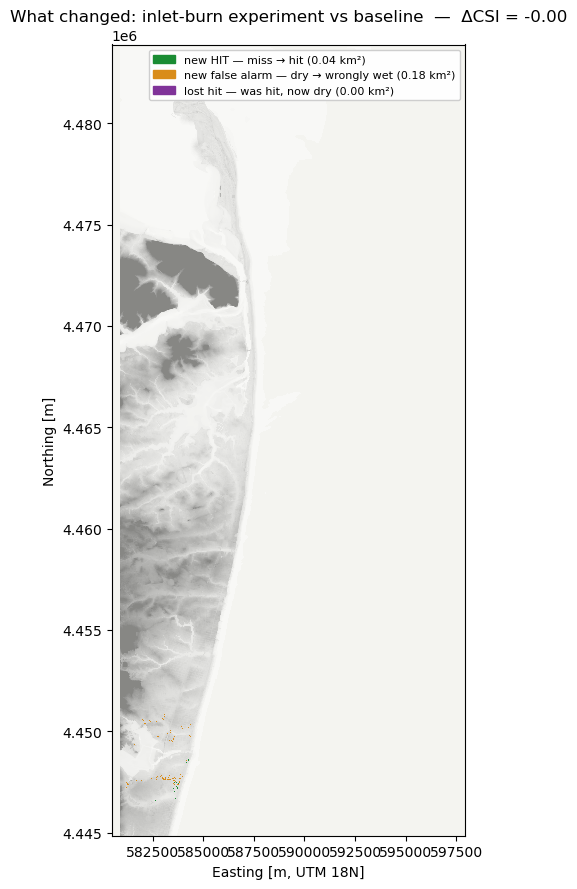

In [25]:
# Compare experiment vs baseline (the working model/ run).
# Recomputes the MOTF metrics on the baseline output independently, then reports
# the deltas and a "what changed" map. Uses ONLY READS on ../model/ — does not
# modify the baseline at all.
import numpy as np
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from hydromt_sfincs import SfincsModel, utils
from pathlib import Path

DEPTH_MIN = 0.15

def motf_score(model_dir):
    m = SfincsModel(model_dir, data_libs=data_libs, mode="r")
    m.output.read()
    zsmax = m.output.data["zsmax"].max(dim="timemax")
    dep = m.data_catalog.get_rasterdataset(
        str(Path(model_dir).resolve() / "subgrid" / "dep_subgrid.tif"))
    hmax = utils.downscale_floodmap(zsmax=zsmax, dep=dep, hmin=0.05)
    def _2d(a): return a.values[0] if a.values.ndim == 3 else a.values
    dep_v, h_v = _2d(dep), _2d(hmax)
    with rasterio.open("/home/zagreus/nj_sandy_sfincs/data/validation/sandy_motf_extent.tif") as r:
        mot = r.read(1); mtf = r.transform; nd = r.nodata
    mod_t = dep.rio.transform(); mh_, mw_ = mot.shape
    Xc = mtf.c + (np.arange(mw_) + 0.5) * mtf.a
    Yc = mtf.f + (np.arange(mh_) + 0.5) * mtf.e
    mc = np.clip(((Xc - mod_t.c) / mod_t.a).astype(int), 0, dep_v.shape[-1] - 1)
    mr = np.clip(((Yc - mod_t.f) / mod_t.e).astype(int), 0, dep_v.shape[-2] - 1)
    rr, cc = np.meshgrid(mr, mc, indexing="ij")
    motf_wet = (mot == 1)
    mod_wet  = (h_v[rr, cc] >= DEPTH_MIN) & np.isfinite(h_v[rr, cc])
    land_in  = (mot != nd) & (dep_v[rr, cc] > 0.0)
    return motf_wet, mod_wet, land_in, mtf, dep_v, mod_t

def stats(motf_wet, mod_wet, land_in):
    nh = int((motf_wet & mod_wet & land_in).sum())
    nm = int((motf_wet & ~mod_wet & land_in).sum())
    nf = int((~motf_wet & mod_wet & land_in).sum())
    CSI = nh / (nh + nm + nf) if (nh + nm + nf) else 0.0
    POD = nh / (nh + nm) if (nh + nm) else 0.0
    FAR = nf / (nh + nf) if (nh + nf) else 0.0
    return nh, nm, nf, CSI, POD, FAR

motf_w, exp_wet, land, mtf, dep_v_ref, mod_t_ref = motf_score("../model_inlet_test")
_,     bas_wet, _,    _,   _,         _          = motf_score("../model")

eh, em, ef, eCSI, ePOD, eFAR = stats(motf_w, exp_wet, land)
bh, bm, bf, bCSI, bPOD, bFAR = stats(motf_w, bas_wet, land)
PIX = mtf.a * abs(mtf.e) / 1e6
print(f"{'metric':<22}{'baseline':>12}{'experiment':>14}{'delta':>10}")
for name, b, e_ in [("CSI", bCSI, eCSI), ("POD (hit rate)", bPOD, ePOD), ("FAR", bFAR, eFAR)]:
    print(f"{name:<22}{b:12.2f}{e_:14.2f}{e_ - b:+10.2f}")
print(f"\nareas (km^2):  hit  miss  false-alarm")
print(f"  baseline    : {bh*PIX:5.1f} {bm*PIX:5.1f} {bf*PIX:5.1f}")
print(f"  experiment  : {eh*PIX:5.1f} {em*PIX:5.1f} {ef*PIX:5.1f}")

# What changed: where the experiment WET land cells differ from baseline.
became_wet = exp_wet & ~bas_wet & land   # new flooding (good if it fills a miss)
became_dry = bas_wet & ~exp_wet & land   # lost flooding (bad if it was a hit)
new_hit    = became_wet & motf_w         # the win we hoped for
new_FA     = became_wet & ~motf_w        # leaked into MOTF-dry land
lost_hit   = became_dry & motf_w         # regression
print(f"\ncells changed by the burn: +{int(became_wet.sum()*PIX*1000):d} k m² wet, "
      f"-{int(became_dry.sum()*PIX*1000):d} k m² dry  "
      f"(of which: new hit {int(new_hit.sum()*PIX*1000):d}k, new FA {int(new_FA.sum()*PIX*1000):d}k, "
      f"lost hit {int(lost_hit.sum()*PIX*1000):d}k)")

cat = np.zeros_like(motf_w, dtype="uint8")
cat[new_hit] = 1; cat[new_FA] = 2; cat[lost_hit] = 3
cmap = ListedColormap([(1, 1, 1, 0),
                       (0.10, 0.55, 0.20, 1.0),   # new hit  (green)
                       (0.85, 0.55, 0.10, 1.0),   # new FA   (orange)
                       (0.50, 0.20, 0.60, 1.0)])  # lost hit (purple)
ext = [mtf.c, mtf.c + mtf.a * cat.shape[1],
       mtf.f + mtf.e * cat.shape[0], mtf.f]
mod_ext = [mod_t_ref.c, mod_t_ref.c + dep_v_ref.shape[-1] * mod_t_ref.a,
           mod_t_ref.f + dep_v_ref.shape[-2] * mod_t_ref.e, mod_t_ref.f]

fig, ax = plt.subplots(figsize=(7.5, 9))
ax.set_facecolor("#f4f4f0")
ax.imshow(dep_v_ref, extent=mod_ext, cmap="Greys", vmin=-5, vmax=20, alpha=0.45,
          origin="upper", interpolation="nearest")
ax.imshow(cat, cmap=cmap, vmin=0, vmax=3, extent=ext, origin="upper", interpolation="nearest")
ax.set_aspect("equal"); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
ax.set_xlabel("Easting [m, UTM 18N]"); ax.set_ylabel("Northing [m]")
ax.legend(handles=[
    Patch(color=cmap(1), label=f"new HIT — miss → hit ({new_hit.sum() * PIX:.2f} km²)"),
    Patch(color=cmap(2), label=f"new false alarm — dry → wrongly wet ({new_FA.sum() * PIX:.2f} km²)"),
    Patch(color=cmap(3), label=f"lost hit — was hit, now dry ({lost_hit.sum() * PIX:.2f} km²)"),
], loc="upper right", fontsize=8, framealpha=0.95)
ax.set_title(f"What changed: inlet-burn experiment vs baseline  —  ΔCSI = {eCSI - bCSI:+.2f}")
plt.tight_layout()